# Acompanhamento 1: Análise Exploratória e Limpeza de Dados
**Projeto:** <h2>Competição de Machine Learning - Previsão de Preços de Imóveis (Ames Housing)</h2>
**Equipe:**
* Kalil Smith Pinto Palheta - 2223857
* Gabriel Abreu Cunha De Alencar - 2315097
* Igor Gomes Ximenes - 2217665

## 1. Importação de Bibliotecas e Carregamento dos Dados

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

# Apenas configuração de estilo para os gráficos
sns.set_theme(style="whitegrid")

# Carregamento no base 
df_treino = pd.read_csv('treino.csv')

# Visão inicial do dataset
display(df_treino.head())
print(f"O dataset de treino {df_treino.shape[0]} linhas e {df_treino.shape[1]} colunas.")

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,255,20,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,145000
1,1067,60,RL,59.0,7837,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,178000
2,639,30,RL,67.0,8777,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,5,2008,WD,Normal,85000
3,800,50,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal,175000
4,381,50,RL,50.0,5000,Pave,Pave,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,127000


O dataset de treino 1168 linhas e 81 colunas.


## <h3>2. Análise Exploratória da Variável Alvo (`SalePrice`)</h3>
Antes de analisar as variáveis explicativas, precisamos entender o comportamento dos preços das casas.

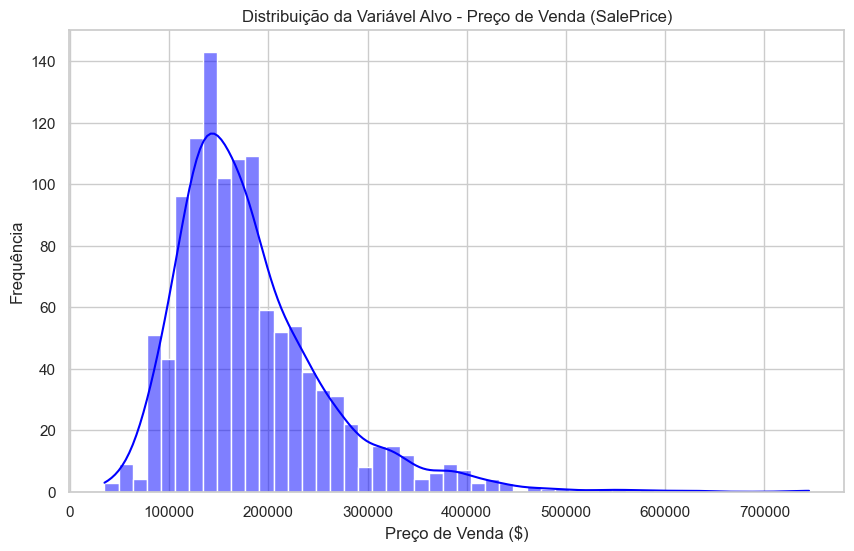

count      1168.000000
mean     181441.541952
std       77263.583862
min       34900.000000
25%      130000.000000
50%      165000.000000
75%      214925.000000
max      745000.000000
Name: SalePrice, dtype: float64


In [2]:
plt.figure(figsize=(10, 6))
sns.histplot(df_treino['SalePrice'], kde=True, color='blue', bins=50)
plt.title('Distribuição da Variável Alvo - Preço de Venda (SalePrice)')
plt.xlabel('Preço de Venda ($)')
plt.ylabel('Frequência')
plt.show()

# Resumo estatístico do SalePrice
print(df_treino['SalePrice'].describe())

# A métrica de avaliação é o RMSLE (logaritmo). 
# Uma assimetria à direita (cauda longa) indica que aplicar log(SalePrice) pode ser benéfico na modelagem.

## <h3>3. Correlação das Variáveis Numéricas</h3>
Vamos identificar quais atributos numéricos possuem maior relação linear com o preço de venda.

Top 10 Variáveis mais correlacionadas com SalePrice:
SalePrice       1.000000
OverallQual     0.801016
GrLivArea       0.723435
GarageCars      0.686763
YearBuilt       0.643216
GarageArea      0.638676
FullBath        0.625567
TotalBsmtSF     0.595014
GarageYrBlt     0.581821
1stFlrSF        0.566305
YearRemodAdd    0.562948
Name: SalePrice, dtype: float64


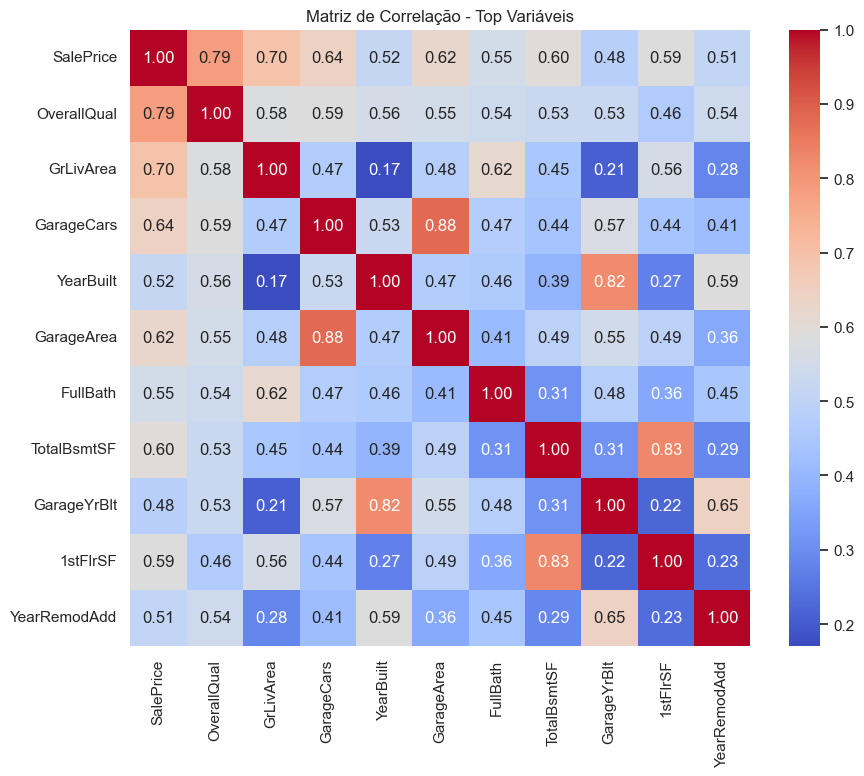

In [3]:
# Selecionar apenas variáveis numéricas
numericas = df_treino.select_dtypes(include=[np.number])

# Calcular a correlação de Spearman (captura relações não-lineares monótonas também)
correlacoes = numericas.corr(method='spearman')['SalePrice'].sort_values(ascending=False)

# Mostrar as 10 variáveis com maior correlação positiva
print("Top 10 Variáveis mais correlacionadas com SalePrice:")
print(correlacoes.head(11)) # Inclui o próprio SalePrice

# Mapa de calor (Heatmap) das variáveis mais importantes
top_features = correlacoes.head(11).index
plt.figure(figsize=(10, 8))
sns.heatmap(df_treino[top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação - Top Variáveis')
plt.show()

## <h3>4. Estratégia de Limpeza de Dados (Valores Ausentes e Outliers) </h3>
Para garantir que o modelo consiga generalizar, precisamos mapear os dados nulos e definir nossa estratégia de inputação.

,Total Nulos,Percentual (%)
PoolQC,1162,99.486301
MiscFeature,1122,96.061644
Alley,1094,93.664384
Fence,935,80.051370
MasVnrType,683,58.476027
FireplaceQu,547,46.832192
LotFrontage,217,18.578767
GarageType,64,5.479452
GarageYrBlt,64,5.479452
GarageFinish,64,5.479452


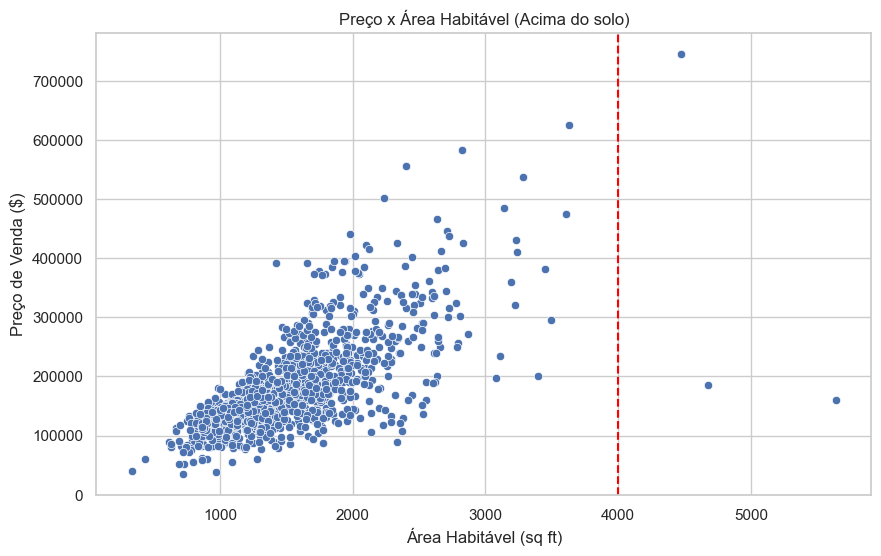

In [4]:
# Mapeamento de dados nulos
nulos = df_treino.isnull().sum()
nulos_percentual = (nulos / len(df_treino)) * 100
df_nulos = pd.DataFrame({'Total Nulos': nulos, 'Percentual (%)': nulos_percentual})
df_nulos = df_nulos[df_nulos['Total Nulos'] > 0].sort_values(by='Percentual (%)', ascending=False)

display(df_nulos)

# VISUALIZAÇÃO DE OUTLIERS: Relação entre Área Habitável (GrLivArea) e Preço
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_treino['GrLivArea'], y=df_treino['SalePrice'])
plt.title('Preço x Área Habitável (Acima do solo)')
plt.xlabel('Área Habitável (sq ft)')
plt.ylabel('Preço de Venda ($)')
# Destacando potenciais outliers (imóveis gigantes muito baratos)
plt.axvline(x=4000, color='red', linestyle='--')
plt.show()

### 4.1 Definição da Estratégia (Próximos Passos para o Pipeline)

Com base nas observações acima, a estratégia a ser codificada no `pipeline.py` será:

1. **Tratamento de Nulos:**
   * Colunas com alto percentual de nulos onde `NaN` significa "ausência da característica" (ex: `PoolQC` - sem piscina, `Alley` - sem beco): Preencheremos com a string `"None"`.
   * Variáveis numéricas contínuas com poucos nulos (ex: `LotFrontage`): Preencheremos com a mediana do respectivo bairro (`Neighborhood`).
2. **Outliers:**
   * Removeremos do conjunto de *treino* os imóveis com `GrLivArea > 4000` e preços anormalmente baixos, pois distorcem a regressão. (Nota: Essa remoção não entra no pipeline final de previsão, apenas na criação do modelo).
3. **Engenharia de Recursos (Feature Engineering):**
   * Criar uma variável combinada de "Área Total" somando a área do porão, 1º e 2º andares.
   * Transformar variáveis de anos (ex: `YearBuilt`) em "Idade do Imóvel".